In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D

# Настройка качественного отображения графиков в Colab
%config InlineBackend.figure_format = 'retina'

In [8]:
# Параметры системы
l1, l2 = 1.0, 0.15
m1, m2, m3 = 5.0, 1.5, 0.5
g = 9.81

Kp = np.diag([200.0, 200.0, 200.0])
Kd = np.diag([50.0, 50.0, 50.0])

# Целевое положение в декартовых координатах Pf (из Предварительной работы)
Pf = np.array([-0.3723076211353316, -0.21495190528383282, 1.075])

q0 = np.array([np.pi/4, 0.1, np.pi/2])
dq0 = np.array([0.0, 0.0, 0.0])
initial_state = np.concatenate((q0, dq0))

In [9]:
# Вспомогательные функции кинематики и динамики ---
def forward_kinematics(q):
    q1, q2, q3 = q
    x = - (l2 * np.cos(q3) + q2) * np.sin(q1)
    y = (l2 * np.cos(q3) + q2) * np.cos(q1)
    z = l1 + l2 * np.sin(q3)
    return np.array([x, y, z])

def get_jacobian(q):
    q1, q2, q3 = q
    J = np.zeros((3, 3))
    J[0, 0] = -(l2 * np.cos(q3) + q2) * np.cos(q1)
    J[0, 1] = -np.sin(q1)
    J[0, 2] = l2 * np.sin(q3) * np.sin(q1)

    J[1, 0] = -(l2 * np.cos(q3) + q2) * np.sin(q1)
    J[1, 1] = np.cos(q1)
    J[1, 2] = -l2 * np.sin(q3) * np.cos(q1)

    J[2, 0] = 0.0
    J[2, 1] = 0.0
    J[2, 2] = l2 * np.cos(q3)
    return J

def robot_dynamics(t, state):
    """Правые части ОДУ"""
    q = state[:3]
    dq = state[3:]
    q1, q2, q3 = q
    dq1, dq2, dq3 = dq

    # Матрица масс M(q)
    M = np.zeros((3, 3))
    M[0, 0] = m2 * q2**2 + m3 * (q2 + l2 * np.cos(q3))**2
    M[1, 1] = m2 + m3
    M[1, 2] = -m3 * l2 * np.sin(q3)
    M[2, 1] = -m3 * l2 * np.sin(q3)
    M[2, 2] = m3 * l2**2

    # Вектор центробежных и кориолисовых сил C(q, dq)*dq
    C = np.zeros(3)
    C[0] = 2 * (m2*q2 + m3*(q2 + l2*np.cos(q3))) * dq1 * dq2 - 2 * m3 * l2 * (q2 + l2 * np.cos(q3)) * np.sin(q3) * dq1 * dq3
    C[1] = -(m2*q2 + m3*(q2 + l2*np.cos(q3))) * dq1**2 - m3 * l2 * dq3**2 * np.cos(q3)
    C[2] = m3 * l2 * (q2 + l2 * np.cos(q3)) * np.sin(q3) * dq1**2

    # Текущее положение и матрица Якоби
    P_curr = forward_kinematics(q)
    J = get_jacobian(q)

    # Скорость в декартовом пространстве
    P_dot = J @ dq

    error = Pf - P_curr
    u = Kp @ error - Kd @ P_dot  # Управляющее воздействие в декартовом пространстве

    # Пересчет декартова управления в обобщенные силы
    # Вектор G(q) взаимно уничтожается
    tau_ctrl = J.T @ u

    # Уравнение: M * ddq + C = tau_ctrl  =>  ddq = M^-1 * (tau_ctrl - C)
    rhs = tau_ctrl - C

    # Решение СЛАУ для поиска ускорений
    try:
        ddq = np.linalg.solve(M, rhs)
    except np.linalg.LinAlgError:
        ddq = np.zeros(3) # Защита от сингулярностей матрицы M

    return np.concatenate((dq, ddq))

In [10]:
# Моделирование (Численное интегрирование)
T_end = 2.0  # Время моделирования (секунды)
t_eval = np.linspace(0, T_end, 1000)

sol = solve_ivp(robot_dynamics, [0, T_end], initial_state, t_eval=t_eval, method='RK45')

# Извлечение результатов
t = sol.t
q1_res, q2_res, q3_res = sol.y[0, :], sol.y[1, :], sol.y[2, :]
dq1_res, dq2_res, dq3_res = sol.y[3, :], sol.y[4, :], sol.y[5, :]

# Расчет декартовых координат для каждого момента времени
x_res, y_res, z_res = np.zeros_like(t), np.zeros_like(t), np.zeros_like(t)
for i in range(len(t)):
    P = forward_kinematics([q1_res[i], q2_res[i], q3_res[i]])
    x_res[i], y_res[i], z_res[i] = P[0], P[1], P[2]

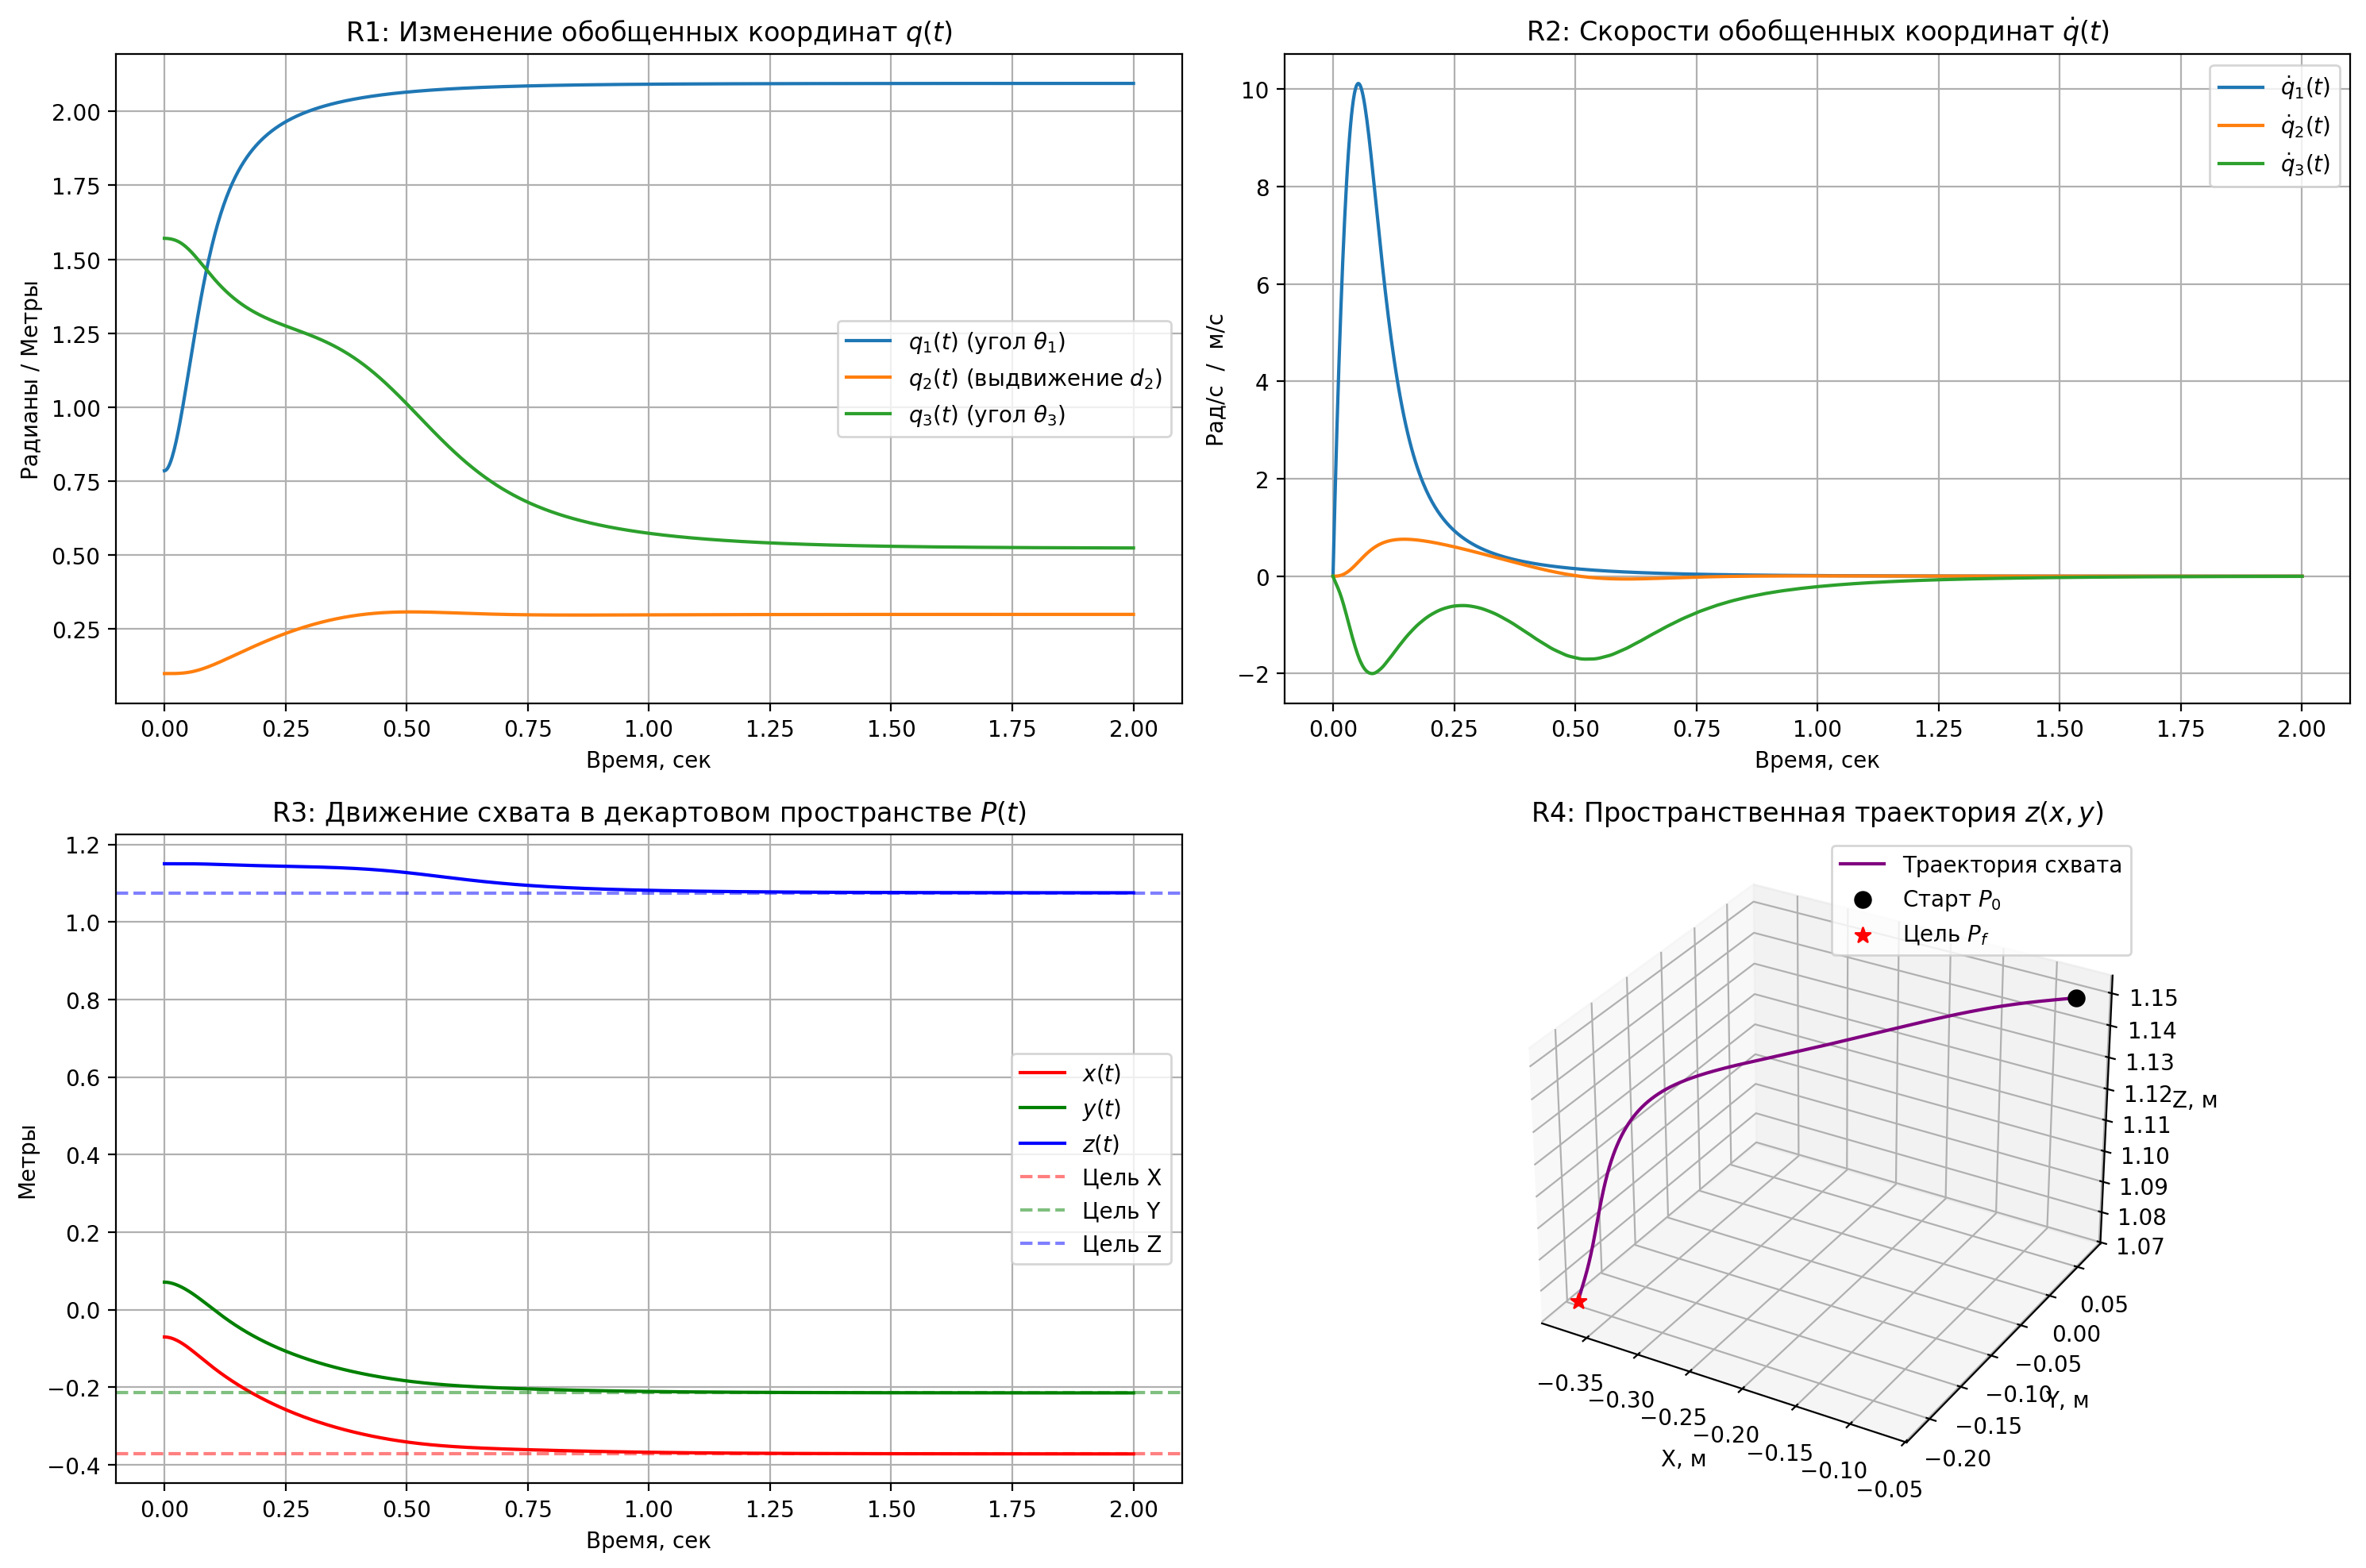

In [11]:
# Построение графиков
fig = plt.figure(figsize=(15, 10))

# R1: Обобщенные координаты
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(t, q1_res, label=r'$q_1(t)$ (угол $\theta_1$)')
ax1.plot(t, q2_res, label=r'$q_2(t)$ (выдвижение $d_2$)')
ax1.plot(t, q3_res, label=r'$q_3(t)$ (угол $\theta_3$)')
ax1.set_title('R1: Изменение обобщенных координат $q(t)$')
ax1.set_xlabel('Время, сек')
ax1.set_ylabel('Радианы / Метры')
ax1.grid(True)
ax1.legend()

# R2: Скорости обобщенных координат
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(t, dq1_res, label=r'$\dot{q}_1(t)$')
ax2.plot(t, dq2_res, label=r'$\dot{q}_2(t)$')
ax2.plot(t, dq3_res, label=r'$\dot{q}_3(t)$')
ax2.set_title(r'R2: Скорости обобщенных координат $\dot{q}(t)$')
ax2.set_xlabel('Время, сек')
ax2.set_ylabel('Рад/с  /  м/с')
ax2.grid(True)
ax2.legend()

# R3: Декартовы координаты
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(t, x_res, label=r'$x(t)$', color='r')
ax3.plot(t, y_res, label=r'$y(t)$', color='g')
ax3.plot(t, z_res, label=r'$z(t)$', color='b')
ax3.grid(True)
ax3.axhline(Pf[0], color='r', linestyle='--', alpha=0.5, label='Цель X')
ax3.axhline(Pf[1], color='g', linestyle='--', alpha=0.5, label='Цель Y')
ax3.axhline(Pf[2], color='b', linestyle='--', alpha=0.5, label='Цель Z')
ax3.set_title('R3: Движение схвата в декартовом пространстве $P(t)$')
ax3.set_xlabel('Время, сек')
ax3.set_ylabel('Метры')
ax3.legend()

# R4: 3D траектория
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.plot(x_res, y_res, z_res, label='Траектория схвата', color='purple')
ax4.scatter([x_res[0]], [y_res[0]], [z_res[0]], color='black', s=50, label='Старт $P_0$')
ax4.scatter([Pf[0]], [Pf[1]], [Pf[2]], color='red', s=50, label='Цель $P_f$', marker='*')
ax4.set_title('R4: Пространственная траектория $z(x, y)$')
ax4.set_xlabel('X, м')
ax4.set_ylabel('Y, м')
ax4.set_zlabel('Z, м')
ax4.grid(True)
ax4.legend()

plt.tight_layout()
plt.show()